# Notebook 06: MLP


from pathlib import Path


In [29]:
import json
import time
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pathlib import Path

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_DIR = next((p for p in candidate_roots if (p / "requirements.txt").exists()), cwd)
DATA_DIR = PROJECT_DIR / "notebooks" / "data"
CLEAN_DIR = PROJECT_DIR / "clean_data"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"


## 1. Load Data & Setup


In [30]:
train = pd.read_csv(CLEAN_DIR / 'train.csv', parse_dates=['week_start'])
test = pd.read_csv(CLEAN_DIR / 'test.csv', parse_dates=['week_start'])

cat_cols = [c for c in train.columns if c.startswith('cat_id_')]
store_cols = [c for c in train.columns if c.startswith('store_id_')]

for df in [train, test]:
    df['cat_id'] = df[cat_cols].idxmax(axis=1).str.replace('cat_id_', '')
    df['store_id'] = df[store_cols].idxmax(axis=1).str.replace('store_id_', '')

target = 'weekly_units'
drop_cols = (['wm_yr_wk', 'week_start', 'n_days', 'month', 'week_of_year', 
              'cat_id', 'store_id', target]
             + cat_cols + store_cols 
             + [c for c in train.columns if c.startswith('state_id_')])
feature_cols = [c for c in train.columns if c not in drop_cols]

combos = sorted(train.groupby(['store_id', 'cat_id']).groups.keys())

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Feature count:', len(feature_cols))
print('Number of store-category models:', len(combos))


Train shape: (6510, 47)
Test shape: (240, 47)
Feature count: 23
Number of store-category models: 30


In [31]:
train_full = train.copy()
sorted_train_weeks = sorted(train_full['wm_yr_wk'].unique())
val_weeks = sorted_train_weeks[-8:]
train_weeks = sorted_train_weeks[:-8]

train_tune = train_full[train_full['wm_yr_wk'].isin(train_weeks)].copy()
val = train_full[train_full['wm_yr_wk'].isin(val_weeks)].copy()

print('Train tuning shape:', train_tune.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)


Train tuning shape: (6270, 47)
Validation shape: (240, 47)
Test shape: (240, 47)


## 2. Metrics and Helpers


In [32]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

def mlp_param_count(input_dim, hidden_layer_sizes):
    dims = [input_dim] + list(hidden_layer_sizes) + [1]
    total = 0
    for in_dim, out_dim in zip(dims[:-1], dims[1:]):
        total += in_dim * out_dim + out_dim
    return total

def summarize_runtime(seconds, n_models):
    return {
        'fit_time_total_sec': seconds,
        'fit_time_avg_sec': seconds / n_models if n_models else np.nan
    }

def run_naive(eval_df, pred_col, name):
    preds_df = eval_df[['week_start', 'store_id', 'cat_id']].copy()
    preds_df['actual'] = eval_df[target].values
    preds_df['predicted'] = eval_df[pred_col].values

    overall = calc_metrics(preds_df['actual'], preds_df['predicted'])
    overall.update({'fit_time_total_sec': 0.0, 'fit_time_avg_sec': 0.0,
                    'estimated_params_per_model': 0, 'estimated_total_params': 0})
    print(f"{name:32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  "
          f"MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")

    combo_df = preds_df.groupby(['store_id', 'cat_id']).apply(
        lambda g: pd.Series(calc_metrics(g['actual'], g['predicted']))).reset_index()

    return preds_df, combo_df, overall

def run_mlp_per_combo(train_df, eval_df, config, model_name):
    all_preds = []
    combo_results = []
    fit_seconds = 0.0
    param_count = mlp_param_count(len(feature_cols), config['hidden_layer_sizes'])

    for store, cat in combos:
        tr = train_df[(train_df['store_id'] == store) & (train_df['cat_id'] == cat)]
        ev = eval_df[(eval_df['store_id'] == store) & (eval_df['cat_id'] == cat)]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(tr[feature_cols])
        X_ev_s = scaler.transform(ev[feature_cols])

        model = MLPRegressor(
            hidden_layer_sizes=config['hidden_layer_sizes'],
            activation='relu',
            alpha=config['alpha'],
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        )

        start = time.perf_counter()
        model.fit(X_tr_s, tr[target])
        fit_seconds += time.perf_counter() - start

        preds = model.predict(X_ev_s)
        metrics = calc_metrics(ev[target], preds)
        metrics['store_id'] = store
        metrics['cat_id'] = cat
        combo_results.append(metrics)

        pred_df = ev[['week_start', 'store_id', 'cat_id']].copy()
        pred_df['actual'] = ev[target].values
        pred_df['predicted'] = preds
        all_preds.append(pred_df)

    all_preds_df = pd.concat(all_preds, ignore_index=True)
    combo_df = pd.DataFrame(combo_results)
    overall = calc_metrics(all_preds_df['actual'], all_preds_df['predicted'])
    overall.update(summarize_runtime(fit_seconds, len(combos)))
    overall['estimated_params_per_model'] = param_count
    overall['estimated_total_params'] = param_count * len(combos)

    print(f"{model_name:32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  "
          f"MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")

    return all_preds_df, combo_df, overall

def fit_final_mlp_artifacts(train_df, config):
    artifacts = {}
    for store, cat in combos:
        tr = train_df[(train_df['store_id'] == store) & (train_df['cat_id'] == cat)]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(tr[feature_cols])

        model = MLPRegressor(
            hidden_layer_sizes=config['hidden_layer_sizes'],
            activation='relu',
            alpha=config['alpha'],
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        )
        model.fit(X_tr_s, tr[target])
        artifacts[f'{store}__{cat}'] = {
            'model': model,
            'scaler': scaler,
            'n_train_rows': len(tr)
        }
    return artifacts

all_results = []


## 3. Naive Baseline


In [33]:
pred_naive_test, combo_naive_test, res = run_naive(test, 'lag_1', 'Naive: Last Week')
all_results.append({'model': 'Naive: Last Week', **res})


Naive: Last Week                  MAE=    655  RMSE=  1,369  MAPE=  6.0%  R²=0.9713


## 4. MLP Tuning

Validation is needed here because the MLP has hyperparameters to choose. We tune on the most recent block of the training window, then retrain on `train + val` for the final test run.


In [34]:
mlp_configs = [
    {'hidden_layer_sizes': (16,), 'alpha': 0.0001},
    {'hidden_layer_sizes': (32,), 'alpha': 0.0001},
    {'hidden_layer_sizes': (32,), 'alpha': 0.001},
    {'hidden_layer_sizes': (32, 16), 'alpha': 0.001},
]

mlp_tuning_rows = []
for cfg in mlp_configs:
    _, _, res = run_mlp_per_combo(train_tune, val, cfg, str(cfg))
    mlp_tuning_rows.append({'model': str(cfg), **res})

mlp_tuning_df = pd.DataFrame(mlp_tuning_rows).set_index('model')
mlp_tuning_df = mlp_tuning_df.round({'MAE': 0, 'RMSE': 0, 'MAPE': 1, 'R2': 4, 'fit_time_total_sec': 3, 'fit_time_avg_sec': 3})
mlp_tuning_df = mlp_tuning_df.sort_values('RMSE')
mlp_tuning_df


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

{'hidden_layer_sizes': (16,), 'alpha': 0.0001}  MAE=  9,647  RMSE= 12,453  MAPE= 96.3%  R²=-1.5365


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

{'hidden_layer_sizes': (32,), 'alpha': 0.0001}  MAE=  9,467  RMSE= 12,356  MAPE= 91.9%  R²=-1.4974


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

{'hidden_layer_sizes': (32,), 'alpha': 0.001}  MAE=  9,467  RMSE= 12,356  MAPE= 91.9%  R²=-1.4974


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

{'hidden_layer_sizes': (32, 16), 'alpha': 0.001}  MAE=  4,843  RMSE=  8,349  MAPE= 34.3%  R²=-0.1402


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params
model,,,,,,,,
"{'hidden_layer_sizes': (32, 16), 'alpha': 0.001}",4843.0,8349.0,34.3,-0.1402,41.161,1.372,1313,39390
"{'hidden_layer_sizes': (32,), 'alpha': 0.0001}",9467.0,12356.0,91.9,-1.4974,33.250,1.108,801,24030
"{'hidden_layer_sizes': (32,), 'alpha': 0.001}",9467.0,12356.0,91.9,-1.4974,33.971,1.132,801,24030
"{'hidden_layer_sizes': (16,), 'alpha': 0.0001}",9647.0,12453.0,96.3,-1.5365,32.751,1.092,401,12030


## 5. Final MLP


In [35]:
best_cfg = eval(mlp_tuning_df.index[0])
trainval = pd.concat([train_tune, val], ignore_index=True)

pred_mlp, combo_mlp, res = run_mlp_per_combo(trainval, test, best_cfg, 'MLP Final')
all_results.append({'model': 'MLP Final', **res})


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

MLP Final                         MAE=  4,816  RMSE=  8,827  MAPE= 32.0%  R²=-0.1916


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## 6. Save Artifacts

Save the final chosen config, feature list, metrics, and the trained per-combo models/scalers so later notebooks can reuse the setup.


In [36]:
cwd = Path.cwd().resolve()
PROJECT_DIR = next((p for p in [cwd, cwd.parent, cwd.parent.parent] if (p / "requirements.txt").exists()), cwd)
artifact_dir = PROJECT_DIR / "artifacts" / "mlp"
artifact_dir.mkdir(parents=True, exist_ok=True)

final_artifacts = fit_final_mlp_artifacts(trainval, best_cfg)
joblib.dump(final_artifacts, artifact_dir / 'mlp_models.joblib')

metadata = {
    'model_name': 'MLP Final',
    'best_config': best_cfg,
    'target': target,
    'feature_cols': feature_cols,
    'combos': [list(c) for c in combos],
    'metrics_test': {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in all_results[-1].items()},
    'artifact_file': str(artifact_dir / 'mlp_models.joblib')
}

with open(artifact_dir / 'mlp_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:', artifact_dir / 'mlp_models.joblib')
print('Saved:', artifact_dir / 'mlp_metadata.json')

/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

Saved: artifacts/mlp/mlp_models.joblib
Saved: artifacts/mlp/mlp_metadata.json


## 7. Model Comparison


In [37]:
results_df = pd.DataFrame(all_results).set_index('model')
results_df = results_df.round({'MAE': 0, 'RMSE': 0, 'MAPE': 1, 'R2': 4, 'fit_time_total_sec': 3, 'fit_time_avg_sec': 3})
results_df


,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params
model,,,,,,,,
Naive: Last Week,655.0,1369.0,6.0,0.9713,0.000,0.000,0,0
MLP Final,4816.0,8827.0,32.0,-0.1916,40.442,1.348,1313,39390


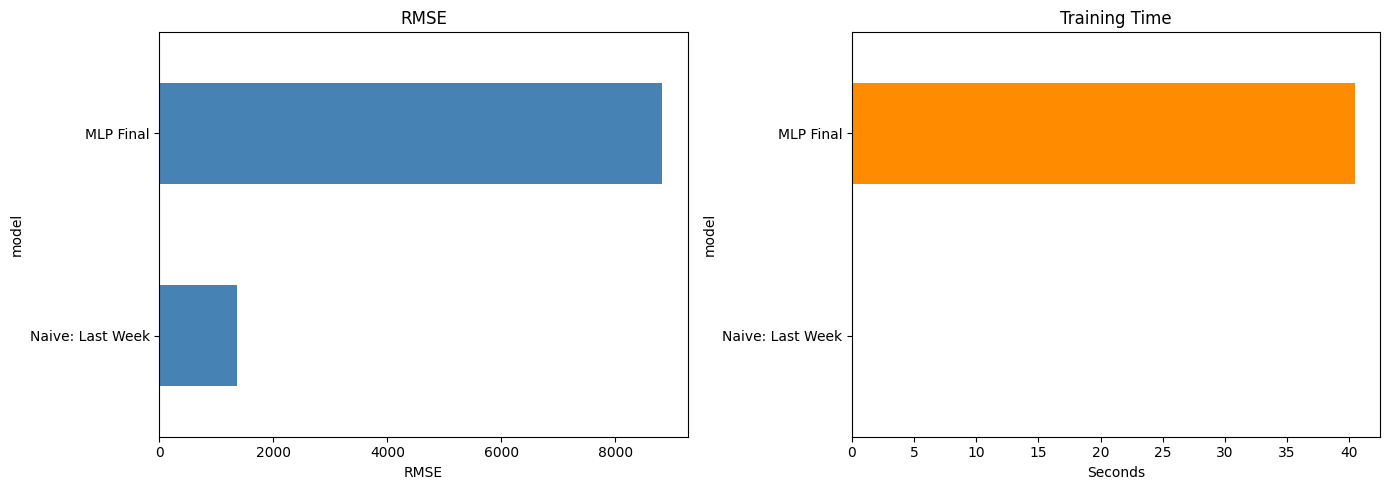

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['RMSE'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('RMSE')
axes[0].set_title('RMSE')

results_df['fit_time_total_sec'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Seconds')
axes[1].set_title('Training Time')

plt.tight_layout()
plt.show()


## 8. Error Analysis


In [39]:
test_analysis = pred_mlp.copy()
test_analysis['error'] = test_analysis['actual'] - test_analysis['predicted']
test_analysis['abs_pct_error'] = (np.abs(test_analysis['error']) / test_analysis['actual']) * 100
test_analysis.head()


,week_start,store_id,cat_id,actual,predicted,error,abs_pct_error
0,2016-03-26,CA_1,FOODS,20496,2897.246254,17598.753746,85.864333
1,2016-04-02,CA_1,FOODS,22389,5115.972406,17273.027594,77.149616
2,2016-04-09,CA_1,FOODS,20850,3588.307343,17261.692657,82.789893
3,2016-04-16,CA_1,FOODS,20842,4849.830289,15992.169711,76.730495
4,2016-04-23,CA_1,FOODS,21064,4386.810510,16677.189490,79.173896


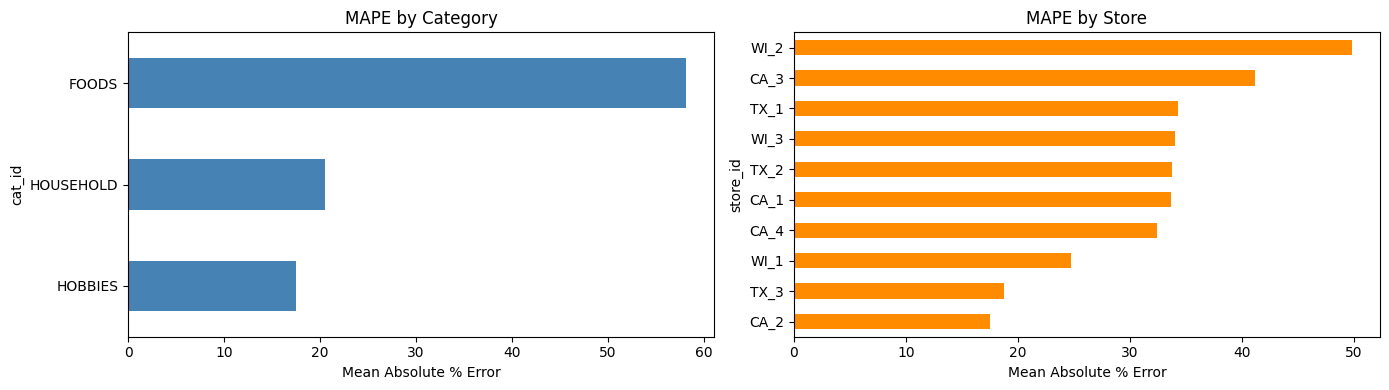

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

test_analysis.groupby('cat_id')['abs_pct_error'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Mean Absolute % Error')
axes[0].set_title('MAPE by Category')

test_analysis.groupby('store_id')['abs_pct_error'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Mean Absolute % Error')
axes[1].set_title('MAPE by Store')

plt.tight_layout()
plt.show()


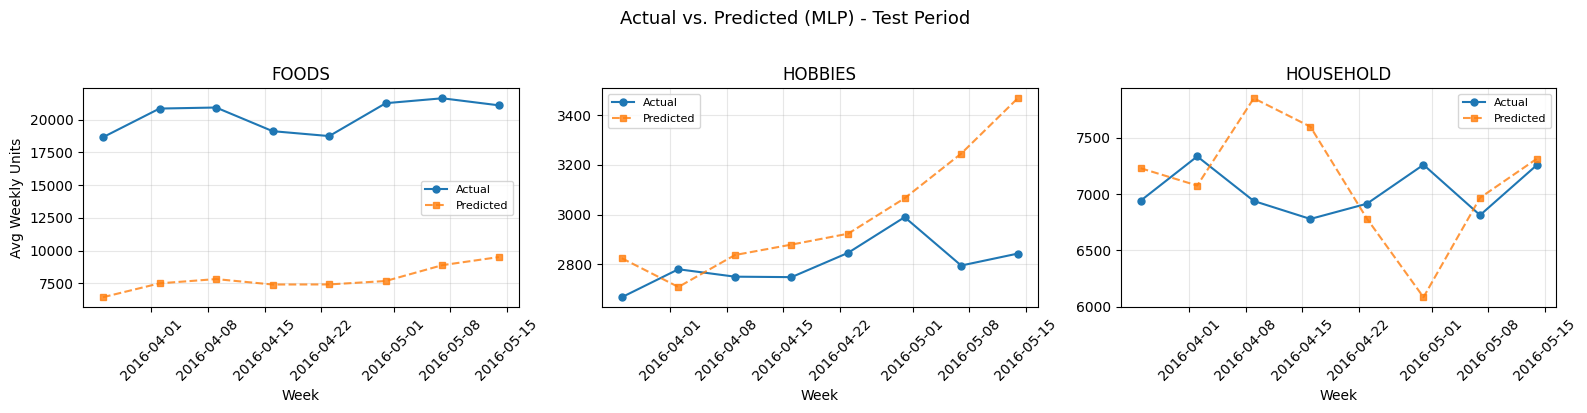

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, cat in zip(axes, sorted(test_analysis['cat_id'].unique())):
    subset = test_analysis[test_analysis['cat_id'] == cat]
    by_week = subset.groupby('week_start')[['actual', 'predicted']].mean()

    ax.plot(by_week.index, by_week['actual'], 'o-', label='Actual', markersize=5)
    ax.plot(by_week.index, by_week['predicted'], 's--', label='Predicted', markersize=5, alpha=0.8)
    ax.set_title(cat)
    ax.set_xlabel('Week')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Avg Weekly Units')
fig.suptitle('Actual vs. Predicted (MLP) - Test Period', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


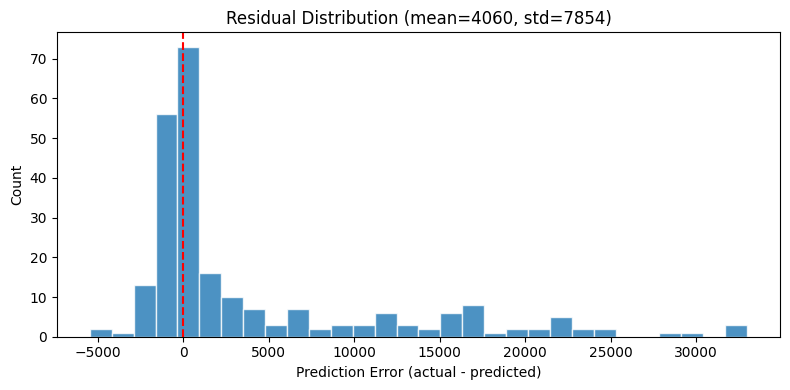

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_analysis['error'], bins=30, edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Prediction Error (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (mean={test_analysis["error"].mean():.0f}, std={test_analysis["error"].std():.0f})')
plt.tight_layout()
plt.show()


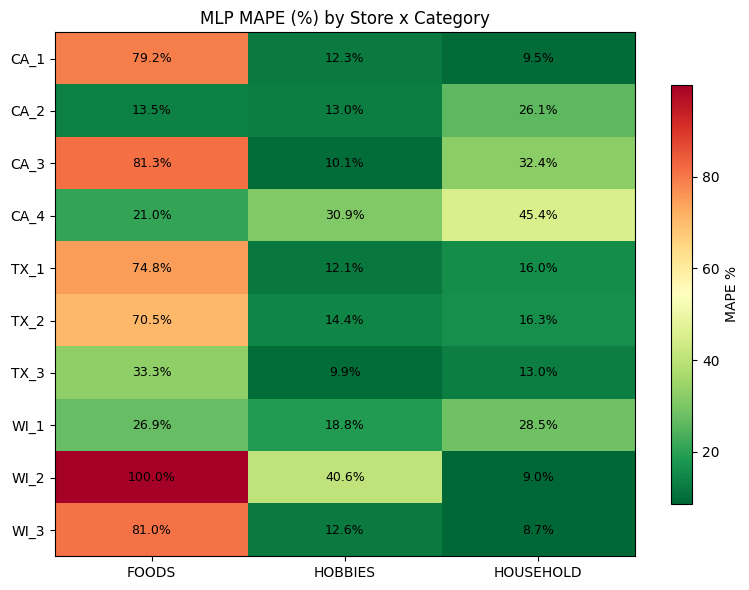

In [43]:
mape_pivot = combo_mlp.pivot_table(index='store_id', columns='cat_id', values='MAPE')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mape_pivot.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(mape_pivot.columns)))
ax.set_xticklabels(mape_pivot.columns)
ax.set_yticks(range(len(mape_pivot.index)))
ax.set_yticklabels(mape_pivot.index)

for i in range(len(mape_pivot.index)):
    for j in range(len(mape_pivot.columns)):
        ax.text(j, i, f'{mape_pivot.values[i, j]:.1f}%', ha='center', va='center', fontsize=9)

ax.set_title('MLP MAPE (%) by Store x Category')
fig.colorbar(im, ax=ax, shrink=0.8, label='MAPE %')
plt.tight_layout()
plt.show()


## 9. Takeaways

- The MLP does **not** appear competitive on this dataset under the current setup. The final model performs much worse than the naive last-week baseline on every major accuracy metric.
- Test performance is poor relative to the baseline: the naive model achieves about `MAE = 655`, `RMSE = 1,369`, and `MAPE = 6.0%`, while the final MLP is around `MAE = 4,816`, `RMSE = 8,827`, and `MAPE = 32.0%`.
- The validation tuning results tell the same story. Among the candidate architectures, `(32, 16)` with `alpha = 0.001` is the least bad, but even that configuration still has negative `R^2` and large forecast errors.
- The repeated convergence warnings suggest the optimizer is struggling to fit stable neural-network models in this problem setting. That supports the interpretation that the MLP is not well matched to the available sample size and feature-to-signal ratio.
- The plots show strong systematic underprediction, especially for high-volume series such as FOODS. The category-level actual-vs-predicted curves and the residual distribution both indicate large positive residuals (`actual - predicted`), meaning the model is consistently predicting values that are too low.
- The store-category MAPE heatmap and category/store error plots suggest that the errors are broadly distributed rather than being confined to only one weak segment. In other words, this is not just a single-category failure.
- From a complexity tradeoff perspective, the MLP is expensive relative to what it delivers here. It takes about `40` seconds total to fit the 30 store-category models and uses about `1,313` parameters per model (`39,390` total), yet still underperforms the zero-cost naive baseline.
- The practical conclusion is that, for this project's current weekly aggregated data and feature set, added neural-network complexity is not justified. This is still a useful result because it strengthens the broader project story: more complex models do not automatically outperform simpler forecasting baselines.
- At the same time, these results should be interpreted as a weak neural-network benchmark rather than proof that neural networks cannot work here. The convergence warnings and poor fit suggest the current MLP may still be under-tuned. Reasonable follow-up improvements would include trying different learning rates, increasing training iterations, transforming the target, or testing a different neural-network training setup. So the current evidence says the MLP is not competitive as implemented, not that neural networks are impossible for this problem.
